#**FinLend — Análise de Carteira de Crédito**

**Contexto**

A FinLend é uma fintech de crédito pessoal que conecta investidores a tomadores de empréstimos via modelo P2P. Este notebook endereça dois dos três desafios técnicos propostos no teste: a análise estatística da inadimplência (Parte 2) e a validação de IA generativa aplicada à carteira (Parte 3).

O ponto de partida é a hipótese levantada pelo Head de Risco: a inadimplência estaria subindo por excesso de aprovações nos graus D e E. A análise vai além dessa hipótese, investigando a composição real da carteira, os segmentos que concentram maior perda esperada e um mecanismo não óbvio que pode estar agravando o risco estruturalmente.

**Dataset**

[Lending Club Loan Data](https://www.kaggle.com/datasets/wordsforthewise/lending-club) (Kaggle)

O arquivo completo contém 2.260.701 registros de 2007 a 2018. Para viabilizar as análises sem comprometer a validade estatística, foi extraída uma amostra aleatória de 150.000 registros distribuídos ao longo de todo o período disponível. Após o filtro de empréstimos com desfecho conhecido (quitado ou inadimplente), a base de trabalho final ficou com 89.192 registros. A representatividade da amostra foi verificada por comparação com a população completa, com diferença máxima de 0,17 p.p. por grade e 0,16 p.p. na taxa de inadimplência.

**Estrutura do notebook**

* FinLend — Análise de Carteira de Crédito (sessão introdutória)
* Análise Estatística com Python
  * Inspeção e preparação dos dados
  * Análise exploratória de inadimplência
  * Teste de hipótese
  * Um insight não-óbvio
  * Recomendação ao negócio
* Curadoria e Validação de IA Generativa
  * Validação quantitativa e qualitativa
  * Proposta de melhoria
  * Proposta de processo recorrente de validação

**Uso de IA assistiva**

Este projeto foi desenvolvido com auxílio do Claude (Anthropic) para estruturação do código e organização do fluxo de trabalho. Todas as decisões analíticas, como seleção de variáveis, definição da variável-alvo, escolha dos testes estatísticos e interpretação dos resultados, foram tomadas e validadas por mim.

Na **Parte 3 — Curadoria e Validação de IA Generativa**, o Claude assume uma função diferente: deixa de ser ferramenta e passa a ser o objeto da análise, sendo o agente avaliado no exercício de validação de IA generativa.

#**Análise Estatística com Python**

##**Inspeção e preparação dos dados**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import gzip
import os

Mounted at /content/drive


In [2]:
base_path = '/content/drive/MyDrive/data_projects/finlend/dataset'
path_accepted = os.path.join(base_path, 'accepted_2007_to_2018Q4.csv.gz')
path_rejected = os.path.join(base_path, 'rejected_2007_to_2018Q4.csv.gz')

In [3]:
df_acc = pd.read_csv(path_accepted, compression='gzip', low_memory=False, nrows=5000)
df_rej = pd.read_csv(path_rejected, compression='gzip', low_memory=False, nrows=5000)

print('accepted:', df_acc.shape)
print('rejected:', df_rej.shape)

accepted: (5000, 151)
rejected: (5000, 9)


In [4]:
display(df_acc.head())
df_acc.info()
display(df_acc.describe())

nulos_acc = df_acc.isnull().sum().sort_values(ascending=False)
display(nulos_acc[nulos_acc > 0].head(20))

for col in ['loan_status', 'grade', 'purpose', 'home_ownership', 'term']:
    if col in df_acc.columns:
        print(f'\n{col}:', df_acc[col].unique())

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 5.8+ MB


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,5.000000e+03,0.0,5000.00000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,46.0,46.000000,46.0,46.000000,34.000000,46.000000,46.000000,133.000000,133.000000,133.000000
mean,6.828371e+07,NaN,15234.35000,15234.35000,15232.78000,12.308078,445.704526,78980.705004,19.291466,0.349400,...,3.0,132.352826,3.0,11.369565,422.337353,11110.432174,177.100000,4960.802707,46.502180,13.526316
std,1.717957e+06,NaN,8647.19714,8647.19714,8645.71224,4.386660,249.055499,46886.647696,8.703863,0.931608,...,0.0,134.932074,0.0,10.390933,385.133156,7734.730919,194.472041,3426.355187,5.208352,7.287992
min,3.617740e+05,NaN,1000.00000,1000.00000,1000.00000,5.320000,31.110000,9000.000000,0.000000,0.000000,...,3.0,5.280000,3.0,0.000000,33.840000,594.070000,0.060000,303.000000,30.000000,1.000000
25%,6.836632e+07,NaN,8400.00000,8400.00000,8400.00000,9.170000,261.305000,50000.000000,12.797500,0.000000,...,3.0,46.897500,3.0,0.000000,147.352500,4824.022500,49.697500,2077.860000,45.000000,8.000000
50%,6.844592e+07,NaN,14150.00000,14150.00000,14150.00000,11.990000,391.560000,70000.000000,18.725000,0.000000,...,3.0,79.450000,3.0,11.000000,314.925000,8710.765000,81.865000,4255.000000,45.000000,15.000000
75%,6.853612e+07,NaN,20000.00000,20000.00000,20000.00000,14.850000,597.780000,98000.000000,25.472500,0.000000,...,3.0,176.665000,3.0,21.000000,578.587500,16342.465000,262.515000,7354.460000,50.000000,18.000000
max,6.861706e+07,NaN,35000.00000,35000.00000,35000.00000,28.990000,1282.790000,675000.000000,83.640000,15.000000,...,3.0,629.700000,3.0,28.000000,1889.100000,28479.590000,756.870000,14950.820000,65.040000,24.000000


,0
member_id,5000
sec_app_num_rev_accts,5000
sec_app_open_act_il,5000
sec_app_inq_last_6mths,5000
sec_app_open_acc,5000
sec_app_mort_acc,5000
sec_app_mths_since_last_major_derog,5000
sec_app_collections_12_mths_ex_med,5000
sec_app_chargeoff_within_12_mths,5000
sec_app_fico_range_low,5000



loan_status: ['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)']

grade: ['C' 'B' 'F' 'A' 'E' 'D' 'G']

purpose: ['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'renewable_energy']

home_ownership: ['MORTGAGE' 'RENT' 'OWN']

term: [' 36 months' ' 60 months']


In [5]:
display(df_rej.head())
df_rej.info()
display(df_rej.describe())

nulos_rej = df_rej.isnull().sum().sort_values(ascending=False)
display(nulos_rej[nulos_rej > 0].head(20))

,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,481xx,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,010xx,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,212xx,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,017xx,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,209xx,MD,< 1 year,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Amount Requested      5000 non-null   float64
 1   Application Date      5000 non-null   object 
 2   Loan Title            5000 non-null   object 
 3   Risk_Score            4908 non-null   float64
 4   Debt-To-Income Ratio  5000 non-null   object 
 5   Zip Code              5000 non-null   object 
 6   State                 5000 non-null   object 
 7   Employment Length     5000 non-null   object 
 8   Policy Code           5000 non-null   float64
dtypes: float64(3), object(6)
memory usage: 351.7+ KB


,Amount Requested,Risk_Score,Policy Code
count,5000.000000,4908.000000,5000.0
mean,8430.917716,548.204360,0.0
std,7183.957717,145.305141,0.0
min,500.000000,0.000000,0.0
25%,3000.000000,492.000000,0.0
50%,5500.000000,567.000000,0.0
75%,12000.000000,640.250000,0.0
max,35000.000000,811.000000,0.0


,0
Risk_Score,92


**Seleção de colunas e carga da amostra**

O arquivo completo tem 151 colunas, a maioria irrelevante para análise de risco: campos administrativos, variáveis para operações conjuntas (todas nulas na inspeção) e informações de hardship. Apenas as colunas com relevância direta para o problema de inadimplência, para o dashboard no Looker Studio e para o documento de validação de IA serão selecionadas para exploração.

Como o arquivo tem mais de 2 milhões de registros e está ordenado cronologicamente, um simples `nrows` carregaria apenas um período específico. Será utilizada amostragem aleatória com seed fixo para garantir representatividade temporal ao longo de todos os anos disponíveis. A validade dessa amostra é verificada na sequência.

A lista de colunas foi definida com base na leitura do dicionário de dados e no contexto do problema. O código de amostragem foi estruturado com auxílio de IA.

In [6]:
cols_accepted = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'issue_d', 'loan_status', 'purpose', 'dti',
    'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'addr_state',
]

print('Contando registros no arquivo completo...')
with gzip.open(path_accepted, 'rt') as f:
    total_linhas = sum(1 for line in f if line.strip()) - 1
print(f'Total de registros: {total_linhas:,}')

np.random.seed(42)
indices_amostra = set(np.random.choice(range(1, total_linhas + 1), size=150_000, replace=False))

df_raw = pd.read_csv(
    path_accepted,
    compression='gzip',
    low_memory=False,
    usecols=cols_accepted,
    skiprows=lambda i: i > 0 and i not in indices_amostra
)

print(f'Shape carregado: {df_raw.shape}')

Contando registros no arquivo completo...
Total de registros: 2,260,701
Shape carregado: (150000, 24)


In [7]:
dup_raw = df_raw.duplicated().sum()
if dup_raw > 0:
    df_raw = df_raw.drop_duplicates().reset_index(drop=True)
    print(f'Duplicatas removidas de df_raw. Shape após remoção: {df_raw.shape}')
else:
    print(f'Nenhuma duplicata encontrada em df_raw.')

dup_rej = df_rej.duplicated().sum()
if dup_rej > 0:
    df_rej = df_rej.drop_duplicates().reset_index(drop=True)
    print(f'Duplicatas removidas de df_rej. Shape após remoção: {df_rej.shape}')
else:
    print(f'Nenhuma duplicata encontrada em df_rej.')

Duplicatas removidas de df_raw. Shape após remoção: (149997, 24)
Duplicatas removidas de df_rej. Shape após remoção: (4998, 9)


**Validação da amostra**

Uma amostra aleatória simples é válida quando representa fielmente a distribuição da população original.

Para verificar isso, será comparada a distribuição por grade e taxa de inadimplência da amostra com os valores do arquivo completo, calculados a partir de uma leitura em chunks para não sobrecarregar a memória. Se as proporções forem próximas, a amostra é representativa e segura para uso na análise e no dashboard.

In [8]:
chunk_size = 100_000
grade_counts_total = {}
status_counts_total = {}

for chunk in pd.read_csv(path_accepted, compression='gzip', low_memory=False,
                          usecols=['grade', 'loan_status'], chunksize=chunk_size):
    for g, c in chunk['grade'].value_counts().items():
        grade_counts_total[g] = grade_counts_total.get(g, 0) + c
    for s, c in chunk['loan_status'].value_counts().items():
        status_counts_total[s] = status_counts_total.get(s, 0) + c

total_pop = sum(grade_counts_total.values())
total_status = sum(status_counts_total.values())

ordem_grade = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
dist_pop = pd.Series(grade_counts_total) / total_pop * 100
dist_amostra = df_raw['grade'].value_counts() / len(df_raw) * 100

comparativo = pd.DataFrame({
    'População (%)': dist_pop.reindex(ordem_grade).round(2),
    'Amostra (%)': dist_amostra.reindex(ordem_grade).round(2),
    'Diferença (p.p.)': (dist_amostra - dist_pop).reindex(ordem_grade).round(2)
})
print('Distribuição por grade: população vs amostra')
display(comparativo)

charged_off_pop = status_counts_total.get('Charged Off', 0)
fully_paid_pop = status_counts_total.get('Fully Paid', 0)
taxa_pop = charged_off_pop / (charged_off_pop + fully_paid_pop)

charged_off_am = (df_raw['loan_status'] == 'Charged Off').sum()
fully_paid_am = (df_raw['loan_status'] == 'Fully Paid').sum()
taxa_am = charged_off_am / (charged_off_am + fully_paid_am)

print(f'\n---\nTaxa de inadimplência (desfechos conhecidos):')
print(f'  População completa: {taxa_pop:.2%}')
print(f'  Amostra:            {taxa_am:.2%}')
print(f'  Diferença:          {abs(taxa_pop - taxa_am):.2%}')

Distribuição por grade: população vs amostra


,População (%),Amostra (%),Diferença (p.p.)
A,19.15,18.99,-0.17
B,29.35,29.27,-0.08
C,28.75,28.86,0.11
D,14.35,14.43,0.08
E,6.00,6.06,0.06
F,1.85,1.85,0.01
G,0.54,0.54,0.00



---
Taxa de inadimplência (desfechos conhecidos):
  População completa: 19.96%
  Amostra:            20.13%
  Diferença:          0.16%


Para que a amostra aleatória simples seja válida, as diferenças por `grade` devem ser inferiores a 1 ponto percentual e a taxa de inadimplência da amostra deve estar próxima da população. Diferenças maiores indicariam necessidade de estratificação por `grade` ou por ano.

Os resultados confirmam a representatividade da amostra. A maior diferença por `grade` é de 0,17 p.p. (grau A), bem abaixo do limiar de 1 p.p. A taxa de inadimplência da amostra (20,13%) diverge apenas 0,16 p.p. da população completa (19,96%).

A amostra aleatória simples é suficiente para as análises subsequentes.

**Definição da variável-alvo**

Será mantido apenas empréstimos com desfecho conhecido: `Fully Paid` e `Charged Off`. Registros em `Current`, `Late` ou `In Grace Period` estão em aberto e incluí-los distorceria a taxa de inadimplência, já que não sabemos o resultado final.

A variável `inadimplente` recebe 1 para `Charged Off` e 0 para `Fully Paid`. Essa será a variável-alvo em toda a análise.

In [9]:
status_finalizados = ['Fully Paid', 'Charged Off']
df = df_raw[df_raw['loan_status'].isin(status_finalizados)].copy()

df['inadimplente'] = (df['loan_status'] == 'Charged Off').astype(int)

print('Shape após filtro:', df.shape)
print('\nDistribuição da variável-alvo:')
print(df['inadimplente'].value_counts())
print(f'\nTaxa geral de inadimplência: {df["inadimplente"].mean():.2%}')

Shape após filtro: (89192, 25)

Distribuição da variável-alvo:
inadimplente
0    71242
1    17950
Name: count, dtype: int64

Taxa geral de inadimplência: 20.13%


**Limpeza, preparação e seleção de variáveis**

* `term`, `int_rate` e `revol_util` são convertidas para numérico: `term` com extração do valor inteiro, as demais com coerção explícita por possível leitura como objeto.
* `fico_medio` é criado como média entre `fico_range_low` e `fico_range_high`, substituindo ambas as colunas originais, já convertido para inteiro na criação.
* `emp_length` é mapeada para numérico em `emp_length_num`; nulos recebem `Unknown` na coluna categórica e `-1` na numérica, pois a ausência de informação de emprego pode ser um sinal em si.
* `issue_d` é convertida para datetime para extração de `ano_emissao` e permanece nesse formato durante todo o processamento.
* Nulos residuais em `revol_util` e `dti` são imputados pela mediana, mais adequada que a média para distribuições assimétricas.
* Colunas de contagem lidas como `float64` por herança de nulos são convertidas para `int64` em bloco único.
* `loan_status` é mantido como referência textual ao lado de `inadimplente`.
* Colunas auxiliares sem uso na EDA, no dashboard ou na validação de IA são removidas.

Ao final, todas as colunas do dataframe de trabalho e seus tipos de dados são exibidos.

As transformações foram identificadas a partir da inspeção dos dados. O código foi acelerado com IA.

In [10]:
df['int_rate']    = pd.to_numeric(df['int_rate'], errors='coerce')
df['revol_util']  = pd.to_numeric(df['revol_util'], errors='coerce')
df['term']        = df['term'].str.strip().str.extract(r'(\d+)').astype(int)
df['issue_d']     = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['ano_emissao'] = df['issue_d'].dt.year
df['fico_medio']  = ((df['fico_range_low'] + df['fico_range_high']) / 2).astype(int)

emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4,  '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8,  '9 years': 9, '10+ years': 10
}
df['emp_length_num'] = df['emp_length'].map(emp_map)

df['emp_length']     = df['emp_length'].fillna('Unknown')
df['emp_length_num'] = df['emp_length_num'].fillna(-1)
df['revol_util']     = df['revol_util'].fillna(df['revol_util'].median())
df['dti']            = df['dti'].fillna(df['dti'].median())

cols_int = ['loan_amnt', 'funded_amnt', 'annual_inc', 'revol_bal',
            'delinq_2yrs', 'open_acc', 'pub_rec', 'total_acc']
df[cols_int] = df[cols_int].astype(int)

colunas_finais = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade',
    'emp_length', 'emp_length_num',
    'home_ownership', 'annual_inc', 'verification_status',
    'issue_d', 'ano_emissao',
    'loan_status', 'inadimplente',
    'purpose', 'dti', 'delinq_2yrs', 'fico_medio',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'addr_state',
]
df = df[colunas_finais].copy()

print(f"Registros : {len(df):,}")
print(f"Período   : {df['issue_d'].min().strftime('%b/%Y')} a {df['issue_d'].max().strftime('%b/%Y')}")
print(f"Inadimp.  : {df['inadimplente'].mean():.2%}")
print(f"Nulos     : {df.isnull().sum().sum()}")
print(f"\nShape     : {df.shape}")
print("\nTipos de dados:")
print(df.dtypes.to_string())

Registros : 89,192
Período   : Jul/2007 a Dec/2018
Inadimp.  : 20.13%
Nulos     : 0

Shape     : (89192, 26)

Tipos de dados:
loan_amnt                       int64
funded_amnt                     int64
term                            int64
int_rate                      float64
installment                   float64
grade                          object
sub_grade                      object
emp_length                     object
emp_length_num                float64
home_ownership                 object
annual_inc                      int64
verification_status            object
issue_d                datetime64[ns]
ano_emissao                     int32
loan_status                    object
inadimplente                    int64
purpose                        object
dti                           float64
delinq_2yrs                     int64
fico_medio                      int64
open_acc                        int64
pub_rec                         int64
revol_bal                       int64


**Exportação para o Looker Studio**

O arquivo exportado é o `accepted_amostra_limpa.csv`, gerado a partir da amostra aleatória validada neste notebook. É uma versão reduzida, limpa e com colunas selecionadas do dataset original, viabilizando o uso direto no Looker Studio sem comprometer a integridade da análise. Esse é o único arquivo exportado e o mesmo utilizado como fonte de dados no dashboard entregue junto com este notebook.

In [11]:
df.to_csv(os.path.join(base_path, 'accepted_amostra.csv'), index=False)

caminho = os.path.join(base_path, 'accepted_amostra.csv')
tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
print(f'accepted_amostra.csv exportado com sucesso.')
print(f'Tamanho: {tamanho_mb:.2f} MB')
print(f'Registros: {len(df):,}')
print(f'Colunas: {df.shape[1]}')

accepted_amostra.csv exportado com sucesso.
Tamanho: 12.66 MB
Registros: 89,192
Colunas: 26


##**Análise exploratória da inadimplência**

O objetivo desta seção é entender o que diferencia um empréstimo quitado de um inadimplente.

A taxa geral de inadimplência da carteira é de 20,13%, levantada na etapa de validação da amostra, e serve como benchmark ao longo de toda a análise: segmentos acima desse valor representam risco elevado; abaixo, risco controlado.


**Visão geral da carteira**

Antes de investigar as causas de inadimplência, precisa-se entender a composição da carteira: como os empréstimos estão distribuídos por grade, finalidade, prazo e ano de emissão.

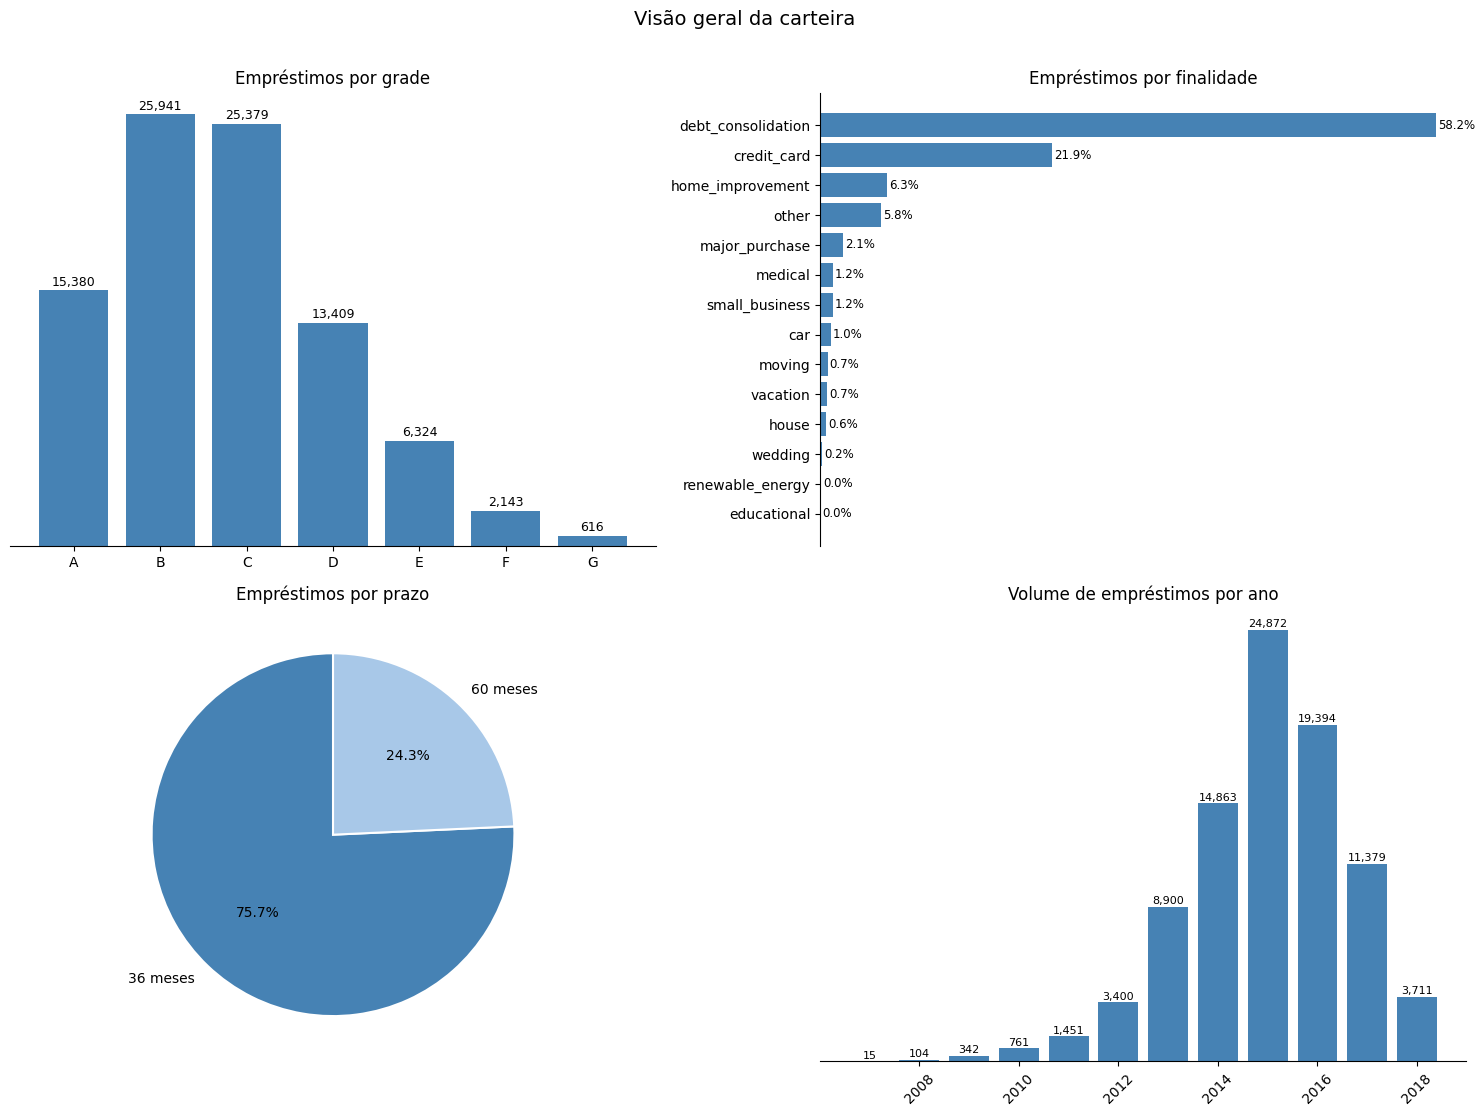

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

ordem_grade = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

fig = plt.figure(figsize=(15, 11))

ax1 = fig.add_subplot(2, 2, 1)
grade_counts = df['grade'].value_counts().reindex(ordem_grade)
bars = ax1.bar(grade_counts.index, grade_counts.values, color='steelblue', edgecolor='none')
ax1.set_title('Empréstimos por grade')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=0)
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

ax2 = fig.add_subplot(2, 2, 2)
purpose_pct = df['purpose'].value_counts(normalize=True).sort_values()
bars2 = ax2.barh(purpose_pct.index, purpose_pct.values, color='steelblue', edgecolor='none')
ax2.set_title('Empréstimos por finalidade')
ax2.set_xticks([])
ax2.set_ylabel('')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
for bar in bars2:
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.1%}', va='center', fontsize=8.5)

ax3 = fig.add_subplot(2, 2, 3)
term_counts = df['term'].value_counts()
ax3.pie(
    term_counts.values,
    labels=[f'{t} meses' for t in term_counts.index],
    autopct='%1.1f%%',
    colors=['steelblue', '#a8c8e8'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax3.set_title('Empréstimos por prazo')

ax4 = fig.add_subplot(2, 2, 4)
ano_counts = df['ano_emissao'].value_counts().sort_index()
bars4 = ax4.bar(ano_counts.index, ano_counts.values, color='steelblue', edgecolor='none')
ax4.set_title('Volume de empréstimos por ano')
ax4.set_xlabel('')
ax4.set_yticks([])
ax4.tick_params(axis='x', rotation=45)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_visible(False)
for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Visão geral da carteira', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Inadimplência por grade**

A taxa de inadimplência é calculada por grade e comparada ao benchmark geral de 20,13%, respondendo diretamente à hipótese do Head de Risco.

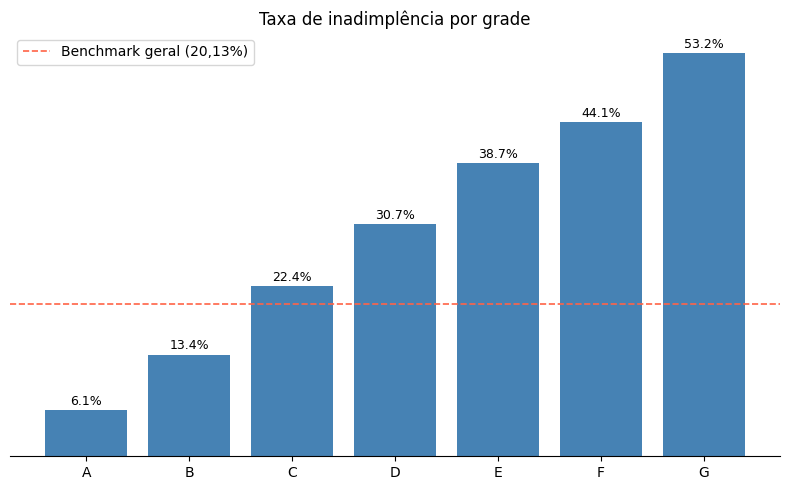

grade
A     6.14%
B    13.41%
C    22.43%
D    30.69%
E    38.69%
F    44.10%
G    53.25%
Name: inadimplente, dtype: object


In [13]:
taxa_por_grade = df.groupby('grade')['inadimplente'].mean().reindex(ordem_grade)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(taxa_por_grade.index, taxa_por_grade.values, color='steelblue', edgecolor='none')
ax.axhline(y=df['inadimplente'].mean(), color='tomato', linestyle='--', linewidth=1.2, label='Benchmark geral (20,13%)')
ax.set_title('Taxa de inadimplência por grade')
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
for bar, val in zip(bars, taxa_por_grade.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

print(taxa_por_grade.apply(lambda x: f'{x:.2%}'))

**Inadimplência por finalidade do empréstimo**

A finalidade do empréstimo é investigada como fator de risco, com atenção especial à consolidação de dívidas, que representa a maior fatia da carteira.

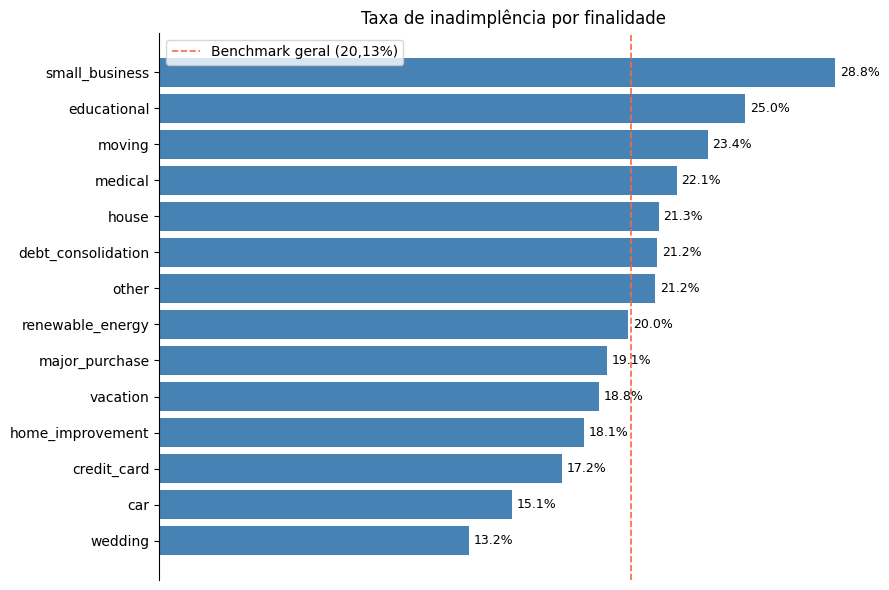

In [14]:
taxa_por_purpose = (
    df.groupby('purpose')['inadimplente']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(taxa_por_purpose.index, taxa_por_purpose['mean'], color='steelblue', edgecolor='none')
ax.axvline(x=df['inadimplente'].mean(), color='tomato', linestyle='--', linewidth=1.2, label='Benchmark geral (20,13%)')
ax.set_title('Taxa de inadimplência por finalidade')
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
for bar, val in zip(bars, taxa_por_purpose['mean']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

**Distribuição de variáveis numéricas por status**

As distribuições de renda anual, taxa de juros, DTI e score de crédito (FICO) são comparadas entre empréstimos quitados e inadimplentes, com o objetivo de identificar separação estatística entre os dois grupos.

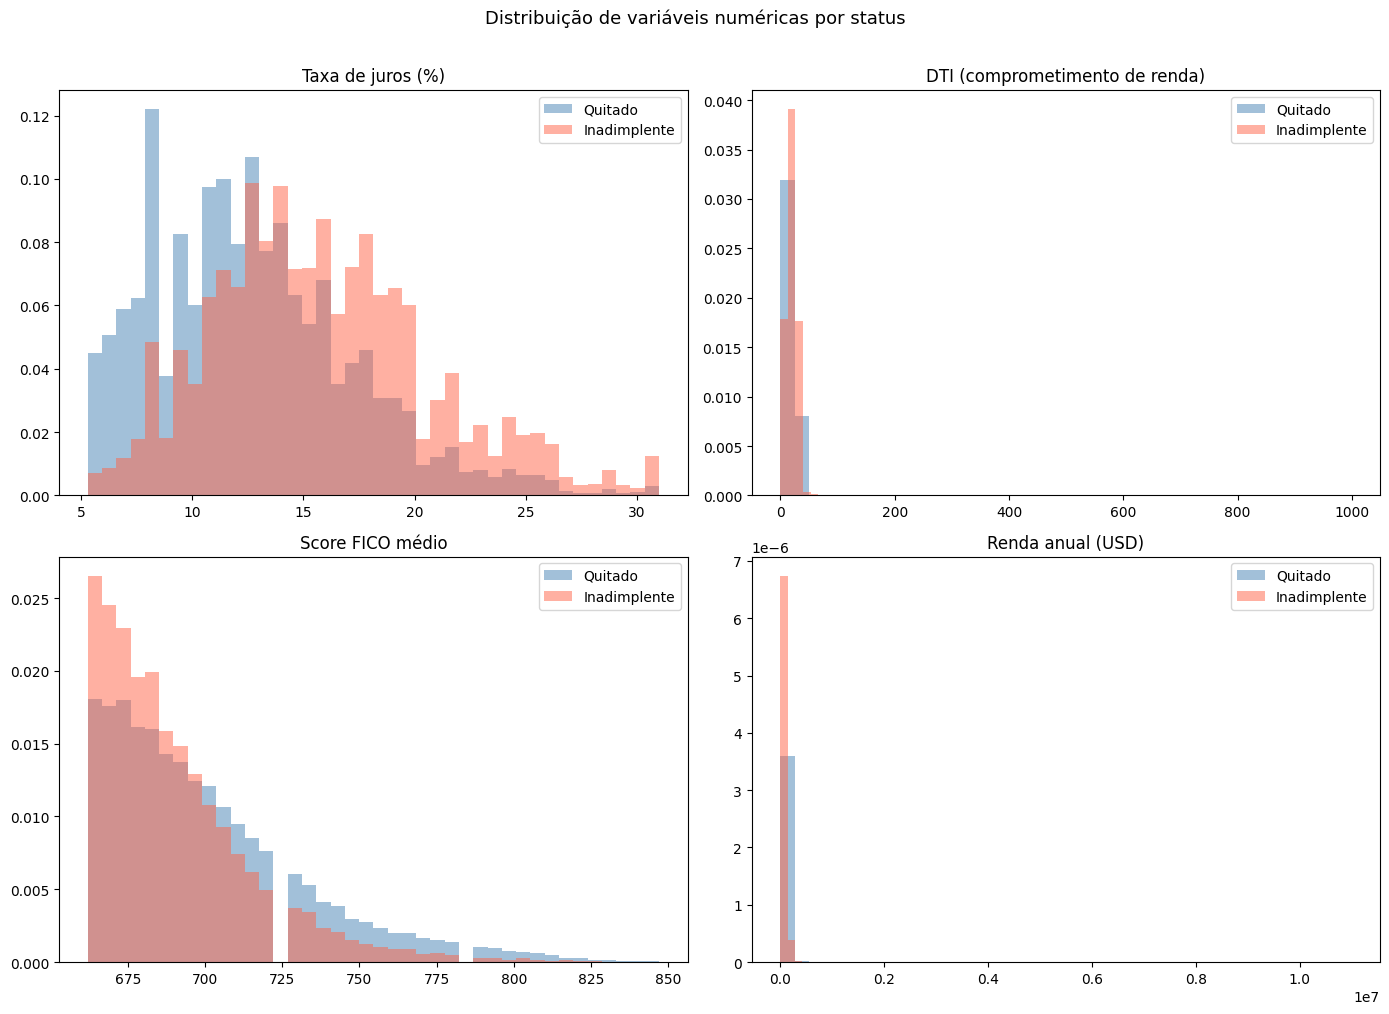

In [15]:
variaveis = {
    'int_rate': 'Taxa de juros (%)',
    'dti': 'DTI (comprometimento de renda)',
    'fico_medio': 'Score FICO médio',
    'annual_inc': 'Renda anual (USD)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(variaveis.items()):
    for status, grupo in df.groupby('inadimplente'):
        nome = 'Inadimplente' if status == 1 else 'Quitado'
        cor = 'tomato' if status == 1 else 'steelblue'
        axes[i].hist(grupo[col].dropna(), bins=40, alpha=0.5, label=nome, color=cor, edgecolor='none', density=True)
    axes[i].set_title(label)
    axes[i].legend()

plt.suptitle('Distribuição de variáveis numéricas por status', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Evolução da inadimplência ao longo do tempo**

A evolução da taxa de inadimplência ao longo dos anos é analisada para verificar se o crescimento da carteira veio acompanhado de deterioração na qualidade do crédito.

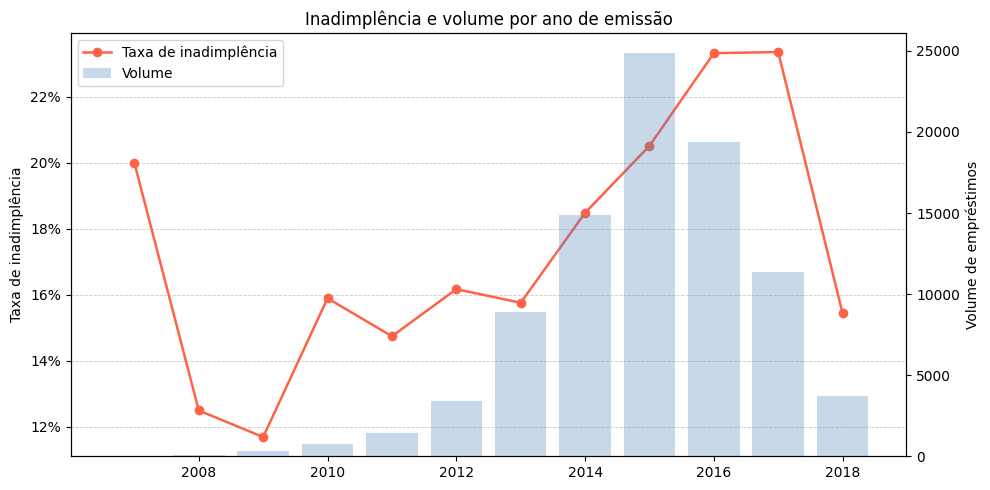

In [16]:
taxa_por_ano = df.groupby('ano_emissao')['inadimplente'].agg(['mean', 'count'])

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(taxa_por_ano.index, taxa_por_ano['mean'], color='tomato', marker='o', linewidth=1.8, label='Taxa de inadimplência', zorder=3)
ax2.bar(taxa_por_ano.index, taxa_por_ano['count'], color='steelblue', alpha=0.3, edgecolor='none', label='Volume')

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax1.set_ylabel('Taxa de inadimplência')
ax2.set_ylabel('Volume de empréstimos')
ax1.set_title('Inadimplência e volume por ano de emissão')

ax1.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#cccccc', zorder=0)
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

**Interpretação dos resultados**

A hipótese levantada pelo Head de Risco, de que a inadimplência está subindo porque a empresa está aprovando muitos empréstimos de graus D e E, é parcialmente verdadeira, mas insuficiente para explicar o fenômeno.

A inadimplência cresce de forma quase monotônica conforme o grau de risco piora, confirmando que o grau é um excelente discriminador. Um empréstimo de grau D ou E tem probabilidade muito maior de inadimplir do que um de grau A ou B, o que valida a premissa básica da hipótese.

No entanto, quando observamos a composição da carteira, a maior parte dos empréstimos está concentrada nos graus B e C, não em D e E. Graus D e E representam cerca de 19% da carteira, enquanto B e C somam mais de 50%. Mesmo com inadimplência menor, B e C geram mais defaults em termos absolutos pelo simples volume que carregam. Como referência: grau E tem 38,7% de inadimplência sobre 6.324 registros, o que resulta em aproximadamente 2.447 inadimplentes. Grau C tem 22,4% sobre 25.379 registros, o que resulta em aproximadamente 5.685 inadimplentes. Grau C, portanto, provavelmente gera mais inadimplentes absolutos do que grau E.

Isso indica que o aumento da inadimplência não pode ser explicado apenas pelo crescimento de D e E sem analisar a composição da carteira ao longo do tempo.

**Crescimento da carteira e deterioração da qualidade**

O gráfico de inadimplência por ano revela um crescimento acelerado do volume de empréstimos emitidos entre 2014 e 2017, período em que a taxa de inadimplência também apresenta trajetória ascendente. Essa associação sugere que a expansão da carteira pode ter sido acompanhada pela entrada de tomadores com perfil de crédito mais arriscado, possivelmente por flexibilização dos critérios de aprovação, ampliação da atuação comercial para perfis de maior risco ou priorização de metas de crescimento em detrimento do controle.

Essa conclusão deve ser interpretada com cautela. A análise por ano de emissão está sujeita a um viés temporal relevante: empréstimos mais recentes tiveram menos tempo para completar seu ciclo de vida e registrar eventos de inadimplência. O status de charged off normalmente ocorre após vários meses de atraso, o que faz com que anos mais recentes apareçam com taxas artificialmente menores. Esse efeito é especialmente visível em 2018, que apresenta queda expressiva. Os dados disponíveis não permitem concluir que houve melhora efetiva na qualidade da carteira naquele ano. Para validar essa hipótese de forma mais robusta, seria necessária uma análise por coortes de originação, comparando empréstimos com o mesmo tempo de maturação.

**Score FICO como principal fator associado à inadimplência**

A distribuição do score FICO apresenta a separação mais clara entre clientes adimplentes e inadimplentes observada em toda a análise. Tomadores inadimplentes concentram-se em faixas mais baixas de score, com distribuição deslocada para a esquerda, enquanto clientes que quitaram seus empréstimos tendem a apresentar scores mais elevados. Nas faixas acima de aproximadamente 800 pontos, a presença de inadimplentes é residual, comportamento compatível com o esperado em operações de crédito.

Esses resultados indicam que o score FICO possui forte poder discriminatório e é um dos melhores candidatos para explicar diferenças de comportamento entre os grupos. Caso seja constatada uma redução do score médio dos clientes aprovados durante o período de maior crescimento da carteira, isso forneceria evidências adicionais de que a expansão das concessões foi acompanhada por deterioração do perfil de risco dos tomadores.

**Taxa de juros e risco de seleção adversa**

A distribuição da taxa de juros mostra inadimplentes concentrados em faixas mais altas e clientes quitados em faixas mais baixas, o que é esperado: juros maiores são cobrados de tomadores com maior risco percebido. Essa relação sugere que a precificação está capturando o risco de forma adequada.

No entanto, existe um risco estrutural a considerar. Se taxas muito elevadas são cobradas para compensar o risco, pode ocorrer seleção adversa: clientes com melhor perfil recusam a oferta por considerá-la cara, enquanto tomadores mais arriscados a aceitam por terem menos alternativas. Esse mecanismo pode amplificar a inadimplência ao longo do tempo e merece atenção na definição da política de precificação.

**DTI com baixo poder discriminatório**

A distribuição do DTI mostra grande sobreposição entre clientes adimplentes e inadimplentes, indicando que essa variável, isoladamente, possui capacidade limitada para diferenciar os dois grupos. Embora o DTI seja tradicionalmente utilizado em modelos de crédito como indicador de capacidade de pagamento, ele não se destacou na análise exploratória.

Um ponto adicional relevante é a presença de um valor extremo próximo de 1000, que provavelmente representa um erro de cadastro. Valores de DTI acima de 100% já são incomuns; um valor de 1000% é incompatível com qualquer situação financeira plausível. Antes de utilizar essa variável em modelos estatísticos, recomenda-se tratar esses registros extremos com *capping* para reduzir sua influência.

**Renda anual e o efeito de mascaramento**

As distribuições de renda anual entre adimplentes e inadimplentes apresentam forte sobreposição, indicando que a renda nominal, por si só, não é suficiente para diferenciar os dois grupos. Também são observados valores extremos que tornam a distribuição bastante assimétrica.

Esse comportamento pode ser explicado pelo efeito de mascaramento: a renda nominal perde capacidade explicativa quando analisada sem contexto, pois o risco de crédito depende não apenas de quanto o cliente ganha, mas de quanto dessa renda já está comprometida com outras obrigações. Por esse motivo, a renda tende a produzir resultados mais relevantes quando combinada ao DTI, que incorpora simultaneamente renda e endividamento.

**Finalidade do empréstimo**

Com o benchmark geral de 20,13%, as finalidades que superam esse nível são: small business (28,8%), educational (25,0%), moving (23,4%), medical (22,1%), house (21,3%), debt consolidation (21,2%) e other (21,2%). As demais ficam abaixo: renewable energy (20,0%), major purchase (19,1%), vacation (18,8%), home improvement (18,1%), credit card (17,2%), car (15,1%) e wedding (13,2%).

A carteira é dominada por debt consolidation (58,2%) e credit card (21,9%), com mais de 80% dos empréstimos concentrados nessas duas categorias. Small business tem a maior taxa de inadimplência, mas representa apenas cerca de 1,2% da carteira, o que limita seu impacto global. Já debt consolidation, apesar de taxa próxima da média, domina o volume e provavelmente responde pela maior quantidade absoluta de defaults.

**Conclusão parcial e hipóteses alternativas**

O Head de Risco está parcialmente correto: graus D e E possuem inadimplência muito superior à média. Porém, os dados não demonstram que eles são os únicos responsáveis pelo aumento recente. As análises exploratórias sugerem hipóteses mais abrangentes:

* o crescimento acelerado da originação entre 2014 e 2017 coincide com a elevação da inadimplência;
* o score FICO médio dos aprovados pode ter caído durante esse período;
* o mix de risco da carteira pode ter se deteriorado;
* a concentração excessiva em debt consolidation expõe a carteira ao comportamento de um único segmento;
* e pode ter havido relaxamento dos critérios de aprovação para sustentar o crescimento.

**Aprofundamento da análise**

Para validar ou refutar definitivamente a hipótese do Head de Risco e explorar as hipóteses alternativas levantadas, a análise segue nos blocos a seguir nesta ordem:

1. Evolução da inadimplência por grau ao longo do tempo: o problema está no mix ou na piora dentro de cada grau?
2. Evolução da composição dos graus ao longo do tempo: a participação de D e E realmente aumentou?
3. Análise de subgrade: há concentração de risco em subgrades específicos ou o salto é gradual?
4. Correlação entre variáveis numéricas: validação estatística das percepções dos histogramas, com a ressalva de que correlação mede relação linear e muitas relações em crédito não são lineares.
5. Ticket médio por grau e finalidade: em vez de perguntar apenas quem inadimpliu mais, perguntamos quem gerou mais perda financeira.

**Evolução da inadimplência por grau ao longo do tempo**

A taxa de inadimplência por grade e por ano de emissão é analisada para distinguir dois cenários: deterioração interna, quando a inadimplência sobe dentro de um mesmo grade ao longo do tempo, e problema de composição, quando as taxas por grade se mantêm estáveis mas o volume dos grades de maior risco cresce.

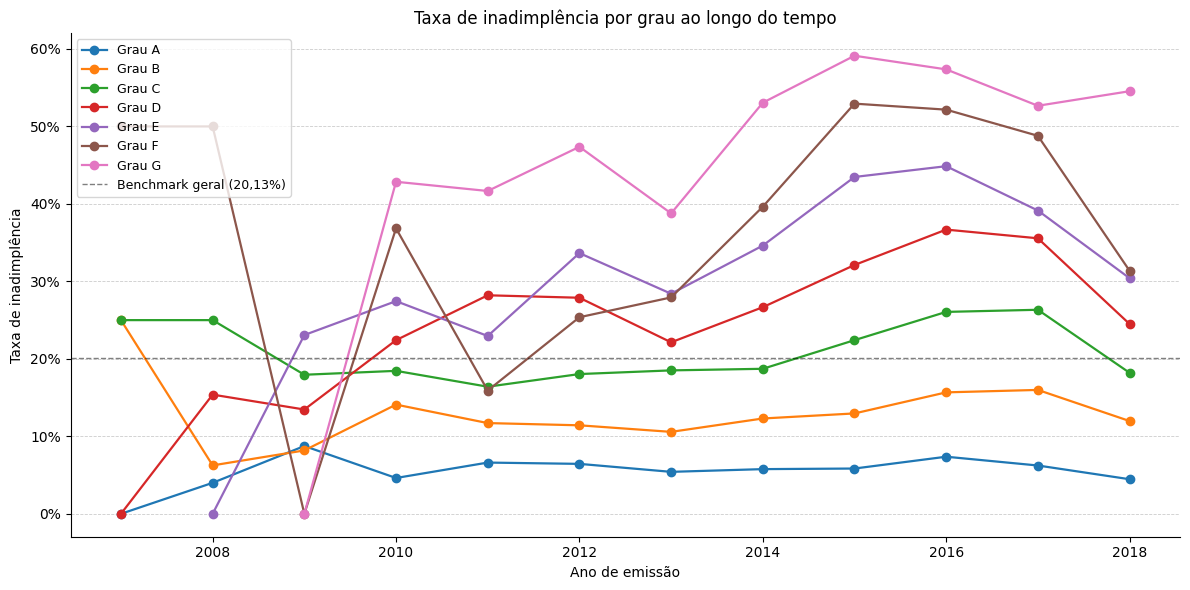

In [17]:
ordem_grade = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

inadimplencia_grade_ano = (
    df.groupby(['ano_emissao', 'grade'])['inadimplente']
    .mean()
    .reset_index()
    .pivot(index='ano_emissao', columns='grade', values='inadimplente')
    .reindex(columns=ordem_grade)
)

cores = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

fig, ax = plt.subplots(figsize=(12, 6))
for grade, cor in zip(ordem_grade, cores):
    if grade in inadimplencia_grade_ano.columns:
        ax.plot(inadimplencia_grade_ano.index, inadimplencia_grade_ano[grade],
                marker='o', label=f'Grau {grade}', color=cor, linewidth=1.6)

ax.axhline(y=df['inadimplente'].mean(), color='black', linestyle='--',
           linewidth=1, alpha=0.5, label='Benchmark geral (20,13%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Taxa de inadimplência por grau ao longo do tempo')
ax.set_xlabel('Ano de emissão')
ax.set_ylabel('Taxa de inadimplência')
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#cccccc')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**O grau é estável no tempo: o problema é de composição, não de deterioração interna**

As taxas por grau se mantêm relativamente estáveis ao longo do tempo dentro de cada categoria. Não há uma degradação clara dentro de cada grau. Isso é importante: significa que o problema não é que os tomadores de grau C, por exemplo, pioraram. O grau continua sendo um bom discriminador consistente. Isso direciona a investigação para o mix da carteira, não para deterioração interna.

**Evolução da composição dos graus ao longo do tempo**

A participação de cada grade ao longo dos anos é analisada para verificar se houve crescimento dos grades de maior risco, o que indicaria mudança no perfil de risco das aprovações durante o período de crescimento acelerado da carteira.

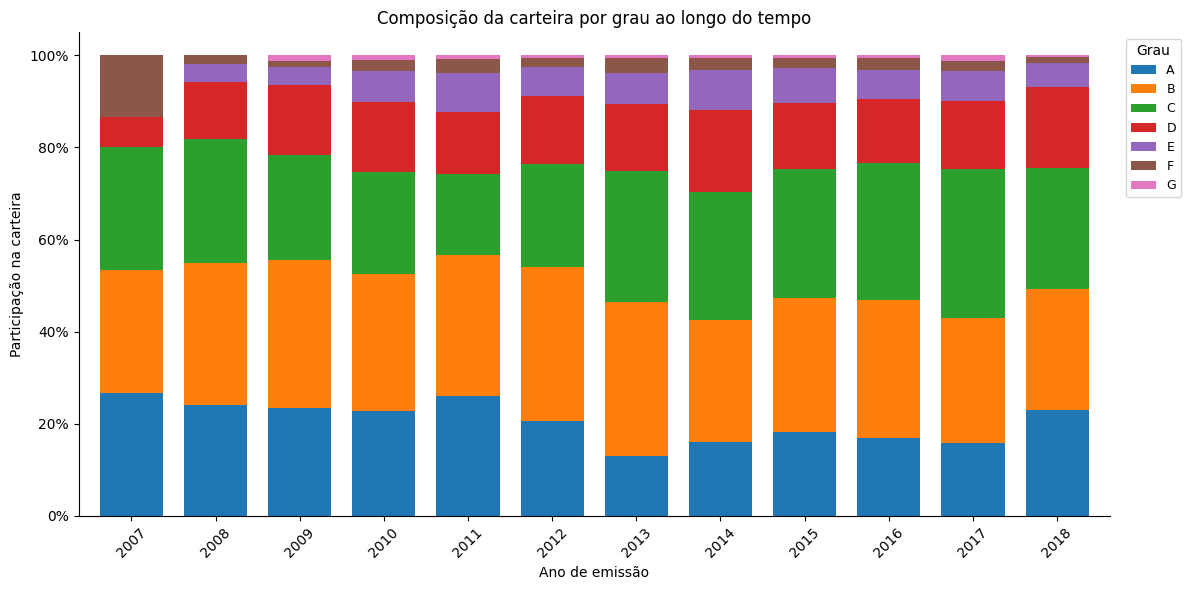

In [18]:
composicao_grade_ano = (
    df.groupby(['ano_emissao', 'grade'])
    .size()
    .reset_index(name='count')
)
composicao_grade_ano['pct'] = (
    composicao_grade_ano.groupby('ano_emissao')['count']
    .transform(lambda x: x / x.sum())
)
composicao_pivot = (
    composicao_grade_ano.pivot(index='ano_emissao', columns='grade', values='pct')
    .reindex(columns=ordem_grade)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(12, 6))
composicao_pivot.plot(
    kind='bar', stacked=True, ax=ax,
    color=cores, edgecolor='none', width=0.75
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Composição da carteira por grau ao longo do tempo')
ax.set_xlabel('Ano de emissão')
ax.set_ylabel('Participação na carteira')
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Grau', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**O crescimento de B e C, não de D e E, explica o aumento dos defaults absolutos**

A participação de grau A caiu de forma visível entre 2007 e 2013 e se manteve baixa. Os graus D e E tiveram crescimento moderado no período de expansão. Mas o movimento mais relevante é o crescimento de B e C juntos, que dominam consistentemente a carteira. Isso reforça a conclusão anterior: o volume absoluto de B e C é o que move a inadimplência agregada, não a explosão de D e E.

**Análise de subgrade**

Dentro de cada grade existem cinco subgrades (A1 a A5, B1 a B5 etc.), com taxas de juros progressivamente maiores. A inadimplência por subgrade é analisada para identificar se o crescimento é gradual e contínuo ou se há pontos de ruptura onde o risco aumenta de forma mais abrupta, o que pode orientar ajustes mais finos na política de aprovação.

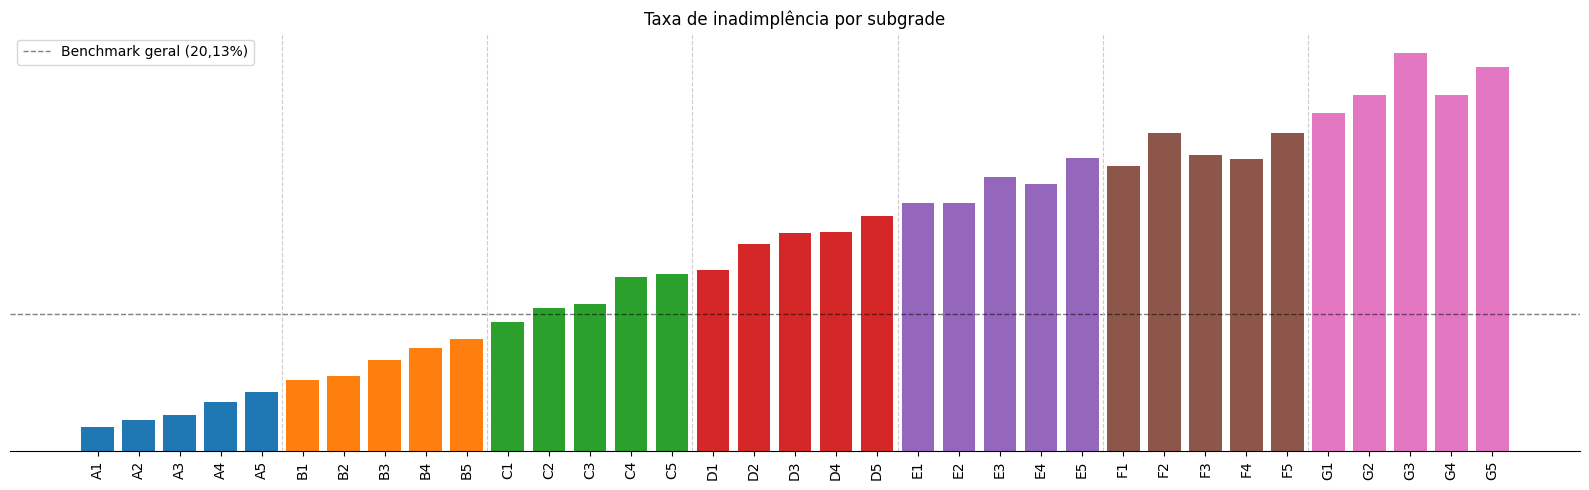

In [19]:
taxa_subgrade = (
    df.groupby('sub_grade')['inadimplente']
    .agg(['mean', 'count'])
    .reset_index()
)

import re
taxa_subgrade['ordem'] = taxa_subgrade['sub_grade'].apply(
    lambda x: (ord(x[0]) - ord('A')) * 5 + int(x[1])
)
taxa_subgrade = taxa_subgrade.sort_values('ordem')

grade_cor = {g: c for g, c in zip(ordem_grade, cores)}
taxa_subgrade['cor'] = taxa_subgrade['sub_grade'].apply(lambda x: grade_cor.get(x[0], 'gray'))

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(taxa_subgrade['sub_grade'], taxa_subgrade['mean'],
              color=taxa_subgrade['cor'], edgecolor='none')
ax.axhline(y=df['inadimplente'].mean(), color='black', linestyle='--',
           linewidth=1, alpha=0.5, label='Benchmark geral (20,13%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Taxa de inadimplência por subgrade')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=90)
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.legend()

for pos in [5, 10, 15, 20, 25, 30]:
    ax.axvline(x=pos - 0.5, color='#cccccc', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

**A progressão de risco é gradual e contínua: o sistema de classificação está bem calibrado**

A progressão é quase perfeitamente monotônica do A1 ao G5, sem pontos de ruptura bruscos. O risco cresce de forma gradual e contínua. Isso valida o sistema de classificação do Lending Club como bem calibrado e não sugere nenhum subgrade específico como outlier que mereça ação isolada.

**Correlação entre variáveis numéricas**

O heatmap de correlação quantifica as relações lineares entre as principais variáveis numéricas e a variável-alvo. As relações esperadas são correlação negativa entre FICO e inadimplência e positiva entre taxa de juros e inadimplência. Correlação mede apenas relações lineares: variáveis com valor próximo de zero podem ainda ter relação não linear relevante com a inadimplência, como é o caso da renda.

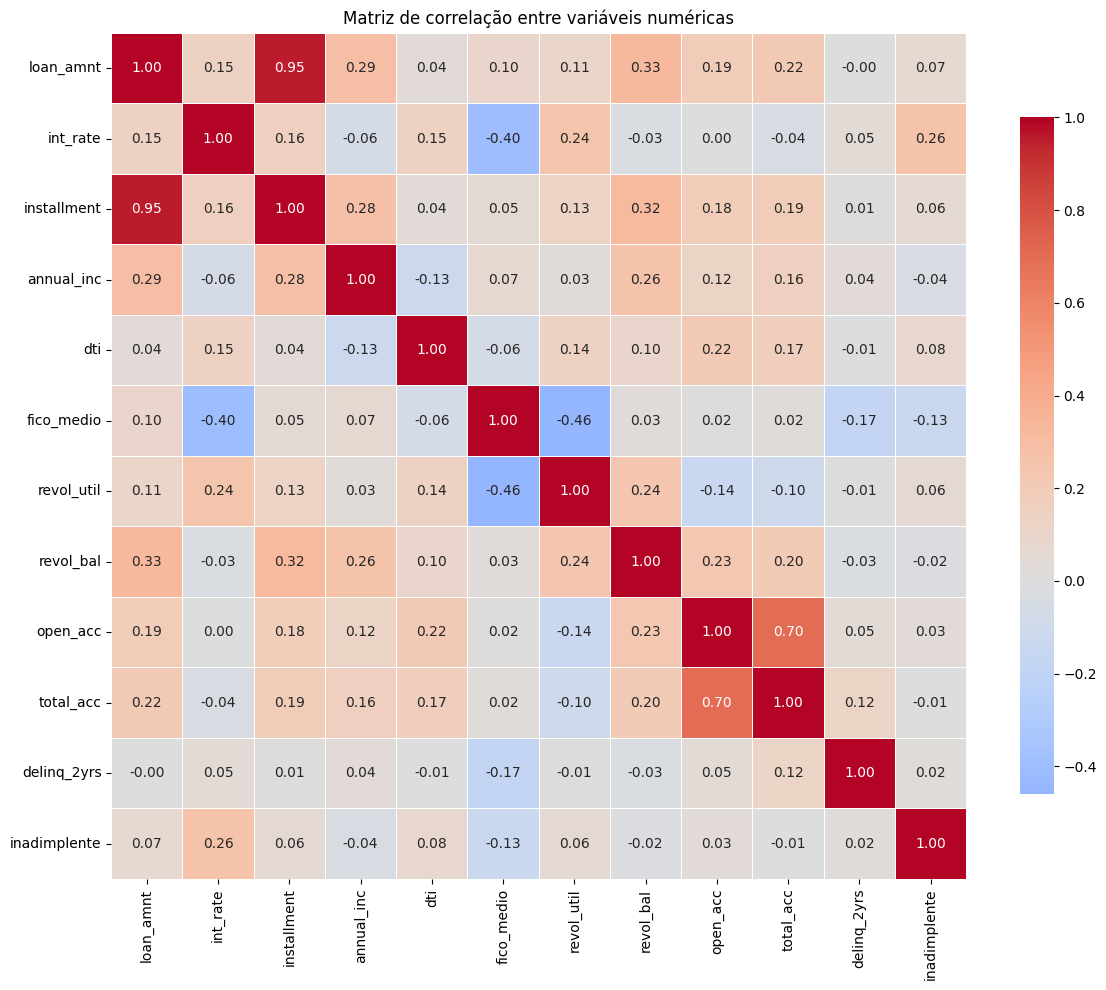

Correlação com inadimplência (ordenada):
int_rate        0.2595
fico_medio     -0.1320
dti             0.0824
loan_amnt       0.0694
revol_util      0.0627
installment     0.0555
annual_inc     -0.0370
open_acc        0.0305
delinq_2yrs     0.0200
revol_bal      -0.0200
total_acc      -0.0080
Name: inadimplente, dtype: object


In [20]:
variaveis_corr = ['loan_amnt', 'int_rate', 'installment', 'annual_inc',
                   'dti', 'fico_medio', 'revol_util', 'revol_bal',
                   'open_acc', 'total_acc', 'delinq_2yrs', 'inadimplente']

corr = df[variaveis_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

print('Correlação com inadimplência (ordenada):')
print(corr['inadimplente'].drop('inadimplente').sort_values(key=abs, ascending=False).apply(lambda x: f'{x:.4f}'))

**Taxa de juros e FICO são as variáveis mais associadas à inadimplência, mas o fenômeno é multivariado**

A correlação mais forte com inadimplência é int_rate (0,26), seguida de fico_medio (-0,13). Isso confirma as percepções dos histogramas, mas com valores baixos, o que reforça que o fenômeno é multivariado e não linear. Um detalhe relevante: fico_medio tem correlação de -0,40 com int_rate, o que faz sentido, clientes com FICO mais alto recebem juros menores. Isso cria multicolinearidade potencial em modelos futuros.

**Ticket médio por grau e por finalidade**

Taxa de inadimplência mede frequência, não magnitude. Um segmento com alta inadimplência e ticket baixo pode gerar menos perda financeira do que um segmento com inadimplência moderada e ticket alto. Ticket médio, taxa de inadimplência e volume são combinados para estimar a perda esperada por grau e por finalidade, respondendo não apenas quem inadimpliu mais, mas quem gerou mais risco financeiro para a carteira.

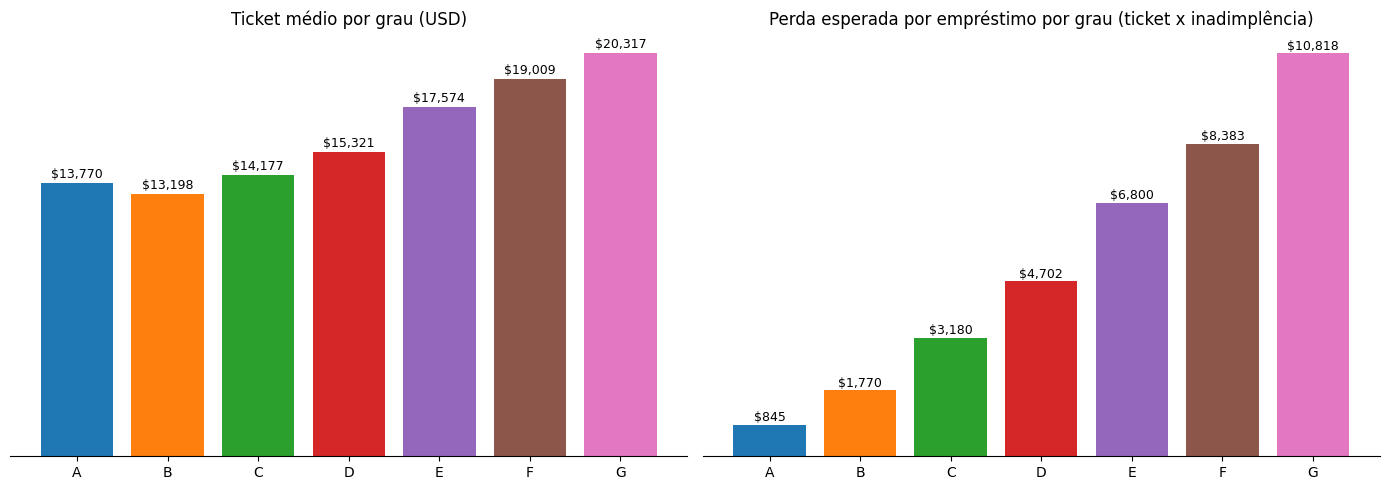

In [21]:
ticket_grade = (
    df.groupby('grade').agg(
        ticket_medio=('loan_amnt', 'mean'),
        taxa_inadimplencia=('inadimplente', 'mean'),
        volume=('loan_amnt', 'count')
    ).reindex(ordem_grade)
)
ticket_grade['perda_esperada'] = ticket_grade['ticket_medio'] * ticket_grade['taxa_inadimplencia']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(ticket_grade.index, ticket_grade['ticket_medio'],
                     color=cores[:len(ticket_grade)], edgecolor='none')
axes[0].set_title('Ticket médio por grau (USD)')
axes[0].set_yticks([])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(ticket_grade.index, ticket_grade['perda_esperada'],
                     color=cores[:len(ticket_grade)], edgecolor='none')
axes[1].set_title('Perda esperada por empréstimo por grau (ticket x inadimplência)')
axes[1].set_yticks([])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(ticket_grade[['ticket_medio','taxa_inadimplencia','perda_esperada','volume']]
      .style.format({'ticket_medio': '${:,.0f}', 'taxa_inadimplencia': '{:.2%}',
                     'perda_esperada': '${:,.0f}', 'volume': '{:,}'}))

**Grau G gera perda esperada 13 vezes maior que grau A: frequência e magnitude contam histórias diferentes**

O ticket médio cresce junto com o risco do grau, o que amplifica a perda esperada nos graus superiores. Grau G tem a maior perda esperada por empréstimo ($10.818), quase 13 vezes maior que grau A ($845). Isso muda completamente a leitura de risco: um único empréstimo de grau G inadimplente representa financeiramente o equivalente a 13 inadimplências de grau A.

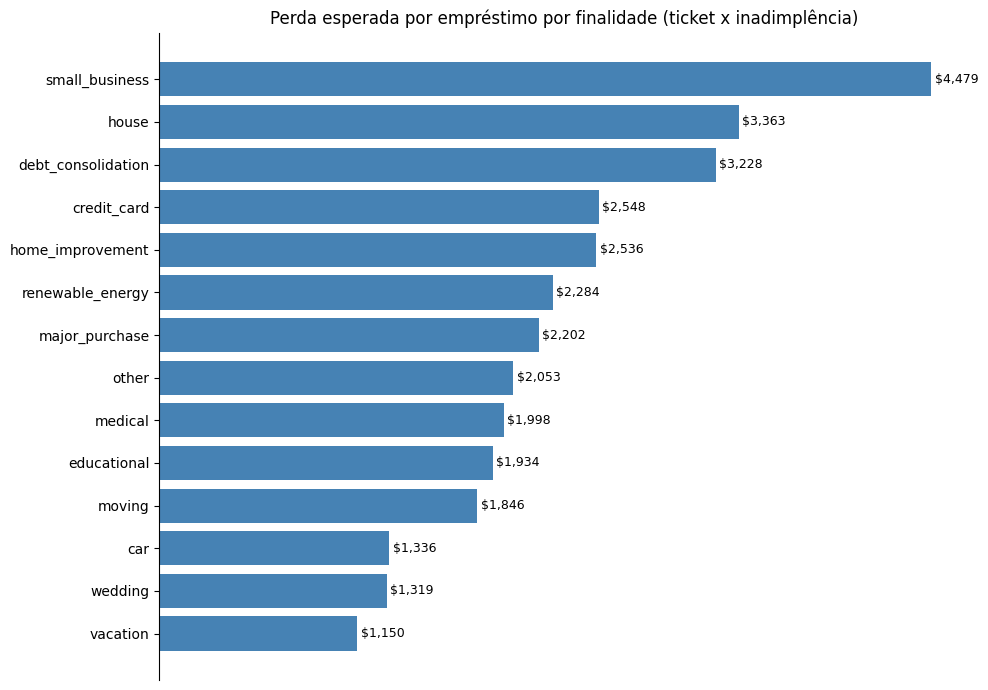

In [22]:
ticket_purpose = (
    df.groupby('purpose').agg(
        ticket_medio=('loan_amnt', 'mean'),
        taxa_inadimplencia=('inadimplente', 'mean'),
        volume=('loan_amnt', 'count')
    )
)
ticket_purpose['perda_esperada'] = ticket_purpose['ticket_medio'] * ticket_purpose['taxa_inadimplencia']
ticket_purpose = ticket_purpose.sort_values('perda_esperada', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(ticket_purpose.index, ticket_purpose['perda_esperada'],
               color='steelblue', edgecolor='none')
ax.set_title('Perda esperada por empréstimo por finalidade (ticket x inadimplência)')
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Small business lidera a perda esperada por empréstimo, mas debt consolidation é o risco sistêmico real**

Small business lidera com $4.479 de perda esperada por empréstimo, não por ter o maior ticket, mas por combinar ticket elevado com a maior taxa de inadimplência da carteira. Debt consolidation aparece em terceiro ($3.228), o que é relevante dado seu volume dominante de 58%. House em segundo ($3.363) surpreende porque tem volume pequeno mas ticket alto.

##**Teste de hipótese**

In [23]:
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

# Qui-quadrado
tabela = pd.crosstab(df['grade'], df['inadimplente'])
chi2, p_chi2, dof, _ = chi2_contingency(tabela)

print("=" * 60)
print("TESTE QUI-QUADRADO: inadimplência entre todos os graus")
print("=" * 60)
print(tabela)
print(f"\nchi²: {chi2:.4f} | gl: {dof} | p-valor: {p_chi2:.6f}")
print(f"Conclusão: {'Rejeita' if p_chi2 < 0.05 else 'Não rejeita'} H0 (α = 0,05)")

# Teste Z de proporções — par a par + B+C vs D+E
print("\n" * 2 + "=" * 60)
print("TESTE Z DE PROPORÇÕES: comparações par a par")
print("=" * 60)

pares = [('A','B'), ('B','C'), ('C','D'), ('D','E'), ('E','F'), ('F','G')]
grupo_bc = df[df['grade'].isin(['B','C'])]
grupo_de = df[df['grade'].isin(['D','E'])]
resultados = []

for g1, g2 in pares:
    d1 = df[df['grade'] == g1]['inadimplente']
    d2 = df[df['grade'] == g2]['inadimplente']
    z, p = proportions_ztest([d1.sum(), d2.sum()], [len(d1), len(d2)])
    resultados.append({
        'Comparação': f'{g1} vs {g2}',
        'Taxa grau 1': f'{d1.mean():.2%}', 'Taxa grau 2': f'{d2.mean():.2%}',
        'Diferença': f'{d2.mean()-d1.mean():+.2%}',
        'Z': f'{z:.4f}', 'P-valor': f'{p:.6f}',
        'Conclusão': 'Significativo' if p < 0.05 else 'Não significativo'
    })

z_bcde, p_bcde = proportions_ztest(
    [grupo_bc['inadimplente'].sum(), grupo_de['inadimplente'].sum()],
    [len(grupo_bc), len(grupo_de)]
)
resultados.append({
    'Comparação': 'B+C vs D+E',
    'Taxa grau 1': f'{grupo_bc["inadimplente"].mean():.2%}',
    'Taxa grau 2': f'{grupo_de["inadimplente"].mean():.2%}',
    'Diferença': f'{grupo_de["inadimplente"].mean()-grupo_bc["inadimplente"].mean():+.2%}',
    'Z': f'{z_bcde:.4f}', 'P-valor': f'{p_bcde:.6f}',
    'Conclusão': 'Significativo' if p_bcde < 0.05 else 'Não significativo'
})
display(pd.DataFrame(resultados))

# Mann-Whitney
print("\n" * 2 + "=" * 60)
print("TESTE DE MANN-WHITNEY: validação não paramétrica")
print("=" * 60)

resultados_mw = []
for g1, g2 in pares:
    d1 = df[df['grade'] == g1]['inadimplente']
    d2 = df[df['grade'] == g2]['inadimplente']
    stat, p = mannwhitneyu(d1, d2, alternative='two-sided')
    r = 1 - (2 * stat) / (len(d1) * len(d2))
    resultados_mw.append({
        'Comparação': f'{g1} vs {g2}', 'Estatística U': f'{stat:.0f}',
        'P-valor': f'{p:.6f}', 'Tamanho do efeito (r)': f'{r:.4f}',
        'Magnitude': 'Pequeno' if abs(r) < 0.1 else ('Médio' if abs(r) < 0.3 else 'Grande'),
        'Conclusão': 'Significativo' if p < 0.05 else 'Não significativo'
    })
display(pd.DataFrame(resultados_mw))

print("\nReferência: |r| < 0,10 pequeno | < 0,30 médio | >= 0,30 grande")

TESTE QUI-QUADRADO: inadimplência entre todos os graus
inadimplente      0     1
grade                    
A             14436   944
B             22462  3479
C             19687  5692
D              9294  4115
E              3877  2447
F              1198   945
G               288   328

chi²: 6156.7307 | gl: 6 | p-valor: 0.000000
Conclusão: Rejeita H0 (α = 0,05)


TESTE Z DE PROPORÇÕES: comparações par a par


,Comparação,Taxa grau 1,Taxa grau 2,Diferença,Z,P-valor,Conclusão
0,A vs B,6.14%,13.41%,+7.27%,-23.1170,0.000000,Significativo
1,B vs C,13.41%,22.43%,+9.02%,-26.6578,0.000000,Significativo
2,C vs D,22.43%,30.69%,+8.26%,-17.8016,0.000000,Significativo
3,D vs E,30.69%,38.69%,+8.01%,-11.1392,0.000000,Significativo
4,E vs F,38.69%,44.10%,+5.40%,-4.4114,0.000010,Significativo
5,F vs G,44.10%,53.25%,+9.15%,-4.0148,0.000060,Significativo
6,B+C vs D+E,17.87%,33.25%,+15.38%,-44.2329,0.000000,Significativo




TESTE DE MANN-WHITNEY: validação não paramétrica


,Comparação,Estatística U,P-valor,Tamanho do efeito (r),Magnitude,Conclusão
0,A vs B,184976932,0.000000,0.0727,Pequeno,Significativo
1,B vs C,299497004,0.000000,0.0902,Pequeno,Significativo
2,C vs D,156098227,0.000000,0.0826,Pequeno,Significativo
3,D vs E,39004976,0.000000,0.0801,Pequeno,Significativo
4,E vs F,6410036,0.000010,0.0540,Pequeno,Significativo
5,F vs G,599652,0.000060,0.0915,Pequeno,Significativo



Referência: |r| < 0,10 pequeno | < 0,30 médio | >= 0,30 grande


**Conclusão do teste de hipótese**

Os três testes aplicados convergem para a mesma conclusão: há diferença estatisticamente significativa na taxa de inadimplência entre todos os graus de risco, em todas as comparações par a par, com p-valor próximo de zero em todos os casos.

O teste qui-quadrado (χ² = 6156,73, gl = 6, p < 0,001) rejeita a hipótese nula de que a inadimplência é igual entre os graus. O teste z de proporções confirma que cada grau difere significativamente do seguinte, com incrementos que variam entre 5,4 e 9,1 pontos percentuais por degrau. A comparação direta entre o bloco B+C (17,87%) e o bloco D+E (33,25%) mostra uma diferença de 15,38 pontos percentuais, também altamente significativa (z = -44,23, p < 0,001).

O teste de Mann-Whitney, aplicado como validação não paramétrica, confirma a significância estatística em todas as comparações. No entanto, os tamanhos de efeito calculados pela correlação rank-biserial são pequenos em todos os pares (|r| entre 0,054 e 0,092), o que é esperado e relevante: com amostras grandes, diferenças reais mas modestas produzem p-valores extremamente baixos. O tamanho do efeito pequeno não invalida a conclusão, mas indica que o grau de risco, isoladamente, explica uma fração limitada da variabilidade da inadimplência. O fenômeno é multivariado.

**Resposta formal à hipótese do Head de Risco**

A afirmação de que graus D e E têm inadimplência significativamente maior do que os demais é estatisticamente correta e confirmada com alto grau de confiança. A diferença não é ruído: é real e consistente.

No entanto, a hipótese de que isso explica o aumento da inadimplência da carteira é insuficiente por dois motivos que os dados demonstram. Primeiro, a composição da carteira está concentrada em B e C, que respondem pela maior parte dos defaults em termos absolutos pelo simples volume que carregam. Segundo, a evolução temporal das taxas por grau mostra estabilidade dentro de cada categoria ao longo dos anos, sem deterioração interna. O problema não está em cada grau piorando, mas no mix da carteira e no crescimento acelerado do volume total entre 2014 e 2017.

A recomendação ao negócio é não tratar grau como único critério de controle de risco. O score FICO, a taxa de juros e a finalidade do empréstimo, em conjunto com o grau, oferecem uma visão mais completa e acionável do risco da carteira.

##**Um insight não-óbvio**

**O sistema de precificação por taxa de juros pode estar criando o problema que tenta resolver.**

A correlação entre `int_rate` e `inadimplente` (0,26) é a mais forte observada na matriz, maior até que a do FICO (-0,13). Isso parece intuitivo: clientes mais arriscados pagam juros maiores. Mas a direção causal pode ser inversa ao esperado.

Quando a plataforma cobra taxas muito altas para compensar o risco percebido, ela filtra os bons pagadores que têm alternativas de crédito mais baratas e retém os tomadores que não conseguem crédito em outro lugar. Esses tomadores aceitam qualquer taxa porque precisam do dinheiro, não porque têm capacidade de pagar. O resultado é que a taxa de juros alta, em vez de compensar o risco, pode estar selecionando ativamente os piores perfis da carteira.

Isso é agravado pelo fato de que `fico_medio` tem correlação de -0,40 com `int_rate`: clientes com FICO alto pagam juros baixos e quitam. Clientes com FICO baixo pagam juros altos e inadimplem. A taxa de juros e o FICO estão capturando o mesmo risco, mas a taxa de juros está amplificando o problema ao encarecer o crédito exatamente para quem tem menor margem financeira.

##**Recomendação ao negócio**

Substituir o monitoramento por grau como métrica primária de risco pelo monitoramento por perda esperada absoluta.

A análise de ticket médio mostrou que grau G gera uma perda esperada de $10.818 por empréstimo, contra $845 do grau A, uma diferença de 13 vezes. Debt consolidation, com 58% da carteira e perda esperada de $3.228 por empréstimo, responde por uma fatia desproporcional do risco total mesmo com taxa de inadimplência próxima da média. Small business, apesar de ter a maior inadimplência (28,8%), representa apenas 1,2% da carteira, o que limita seu impacto agregado.

A recomendação prática é criar um indicador de perda esperada total por segmento (volume x ticket médio x taxa de inadimplência) e monitorá-lo mensalmente no dashboard. Isso permitiria identificar onde a carteira está concentrando risco financeiro real, não apenas frequência de inadimplência, e orientar decisões de aprovação, precificação e limite de exposição por segmento com base em impacto financeiro, não em contagem de eventos.

#**Curadoria e Validação de IA Generativa**

Esta seção avalia a confiabilidade de um agente de linguagem (Claude, da Anthropic) ao responder perguntas analíticas sobre a carteira FinLend. O objetivo não é apenas verificar se os números estão certos, mas construir um método replicável de auditoria para uso recorrente em ambientes de negócio que utilizam IA generativa sobre dados financeiros.

O cenário proposto no teste apresenta a seguinte pergunta feita ao agente: *"Qual é o perfil de risco dos nossos clientes que tomam empréstimos para consolidação de dívidas?"*

A resposta avaliada foi:

> Os clientes que tomam empréstimos para consolidação de dívidas representam 48% da carteira total. A taxa de inadimplência desse segmento é de 12,3%, ligeiramente abaixo da média geral de 14,1%. O ticket médio é de \$15.200 e a renda média anual é de $72.000. A maioria dos clientes está classificada nas grades B e C (62%), indicando um perfil de risco moderado. A taxa de juros média é de 13,8%.

##**Validação quantitativa e qualitativa**

In [24]:
seg = df[df['purpose'] == 'debt_consolidation']

print(f"Participação na carteira: {len(seg) / len(df):.1%}")
print(f"Taxa de inadimplência: {seg['inadimplente'].mean():.1%}")
print(f"Média geral de inadimplência: {df['inadimplente'].mean():.1%}")
print(f"Ticket médio: ${seg['loan_amnt'].mean():,.0f}")
print(f"Renda média anual: ${seg['annual_inc'].mean():,.0f}")
print(f"Taxa de juros média: {seg['int_rate'].mean():.1f}%")
print(f"\nDistribuição por grade:")
print(seg['grade'].value_counts(normalize=True).reindex(ordem_grade).apply(lambda x: f'{x:.1%}'))
print(f"\nParticipação B+C: {seg['grade'].isin(['B','C']).mean():.1%}")

Participação na carteira: 58.2%
Taxa de inadimplência: 21.2%
Média geral de inadimplência: 20.1%
Ticket médio: $15,195
Renda média anual: $74,742
Taxa de juros média: 13.7%

Distribuição por grade:
grade
A    14.4%
B    28.1%
C    29.8%
D    16.2%
E     8.0%
F     2.6%
G     0.7%
Name: proportion, dtype: object

Participação B+C: 57.9%


**Validação Quantitativa**

Cada afirmação numérica do agente é confrontada com o valor real do dataset e classificada como correta (diferença dentro de 1 p.p. ou margem de arredondamento razoável), parcialmente correta (direção e ordem de grandeza adequadas, mas valor impreciso) ou incorreta (divergência que altera a interpretação).

<br>

| Afirmação | Valor declarado | Valor real | Diferença | Classificação |
|:---|:---:|:---:|:---:|:---:|
| Participação na carteira | 48,0% | 58,2% | -10,2 p.p. | Incorreto |
| Taxa de inadimplência do segmento | 12,3% | 21,2% | -8,9 p.p. | Incorreto |
| Média geral de inadimplência | 14,1% | 20,1% | -6,0 p.p. | Incorreto |
| Ticket médio | \$15.200 | \$15.195 | \$5 | Correto |
| Renda média anual | \$72.000 | \$74.742 | \$2.742 | Parcialmente correto |
| Participação B+C | 62,0% | 57,9% | +4,1 p.p. | Parcialmente correto |
| Taxa de juros média | 13,8% | 13,7% | +0,1 p.p. | Correto |
<br><br>

De sete afirmações, duas estão corretas, duas parcialmente corretas e três incorretas. Os três erros concentram-se nas variáveis de maior relevância analítica: participação na carteira, taxa de inadimplência do segmento e benchmark geral. Erros nessas variáveis alteram fundamentalmente qualquer conclusão de risco derivada da análise.

**Avaliação Qualitativa**

* **Coerência interna**<br>A afirmação de que o segmento inadimple ligeiramente abaixo da média é internamente coerente com os valores que o agente declarou. O problema é que ambos os números estão errados. Com os valores reais, a conclusão se inverte: debt consolidation inadimple acima da média geral (21,2% contra 20,1%), não abaixo. A interpretação estava ancorada em dados incorretos e conduz à conclusão oposta à verdadeira.

* **Perfil de risco moderado**<br>A classificação do segmento como de risco moderado, baseada na concentração em grades B e C (57,9%), tem algum mérito descritivo. No entanto, ignora dois fatores que agravam o risco real: o segmento representa 58,2% da carteira e a perda esperada por empréstimo é de $3.228, a terceira maior entre todas as finalidades. Um segmento com inadimplência acima da média e dominância absoluta na carteira não pode ser descrito como de risco moderado sem essas ressalvas.

* **Omissões relevantes**<br>O agente não menciona a perda esperada por empréstimo, que é o indicador mais acionável para decisões de crédito, e não contextualiza o que significa 58,2% de participação na carteira: este segmento sozinho concentra mais risco financeiro total do que todos os outros combinados. A ausência dessas informações limita a resposta a uma descrição superficial, insuficiente para qualquer decisão de gestão de risco.

* **Calibração de incerteza**<br>Os valores foram apresentados com precisão de casas decimais e sem nenhum marcador de incerteza, o que transmite falsa confiança. Em contextos financeiros, respostas sem ressalvas representam risco operacional: o tomador de decisão pode assumir que os números foram verificados quando não foram.

##**Proposta de melhoria**

A resposta do agente deveria ser substituída pela seguinte versão, que corrige os erros quantitativos, ajusta a interpretação e inclui as informações omitidas:

> O segmento de debt consolidation é o maior da carteira FinLend, respondendo por 58,2% dos empréstimos ativos. A taxa de inadimplência do segmento é de 21,2%, marginalmente acima da média geral de 20,1%, o que indica que o segmento não representa um perfil de risco melhor que a carteira como um todo. <br><br> O ticket médio é de \$15.195 e a renda média anual dos tomadores é de \$74.742. A taxa de juros média é de 13,7%. A distribuição por grade está concentrada em B (28,1%) e C (29,8%), que juntas somam 57,9% do segmento. Isso posiciona a maioria dos tomadores em faixas de risco intermediário, com taxas de inadimplência históricas de 13,4% (B) e 22,4% (C). <br><br> O ponto mais relevante para gestão de risco não é a taxa de inadimplência isolada, mas a perda esperada por empréstimo, estimada em \$3.228 (ticket médio multiplicado pela taxa de inadimplência). Combinada com o volume dominante na carteira, isso significa que o segmento de debt consolidation concentra a maior parcela da perda esperada total da carteira. A recomendação é monitorar a exposição absoluta deste segmento mensalmente, não apenas sua taxa de inadimplência relativa.

Essa versão corrige as três afirmações incorretas, mantém as duas corretas, ajusta as parcialmente corretas e acrescenta o contexto de perda esperada que estava ausente na resposta original.

##**Proposta de processo recorrente de validação**

A validação realizada nesta seção foi pontual, aplicada a uma resposta específica sobre um segmento específico. Para que o uso de IA Generativa em análise de carteira seja confiável em ambiente de produção, é necessário um processo sistemático que cubra quatro dimensões: geração controlada de perguntas, verificação quantitativa automatizada, avaliação qualitativa periódica e rastreabilidade de versões.

* **Geração controlada de perguntas**<br>O time de risco deve manter um conjunto fixo de perguntas de referência, denominadas "perguntas âncora", que cubram os principais segmentos e métricas da carteira. Essas perguntas devem ser reaplicadas ao agente sempre que houver atualização de dados ou de modelo. O conjunto mínimo deve incluir perguntas sobre participação de carteira, taxas de inadimplência por segmento, perda esperada por finalidade e evolução temporal das métricas principais.

* **Verificação quantitativa automatizada**<br>Para cada pergunta âncora, deve existir um script Python que extrai o valor correto diretamente do dataset e compara com a resposta do agente. A comparação deve ser expressa em diferença absoluta e percentual, com tolerâncias definidas previamente (por exemplo, diferença menor que 0,5 ponto percentual para taxas, menor que 2% para valores monetários). Qualquer resposta fora da tolerância deve gerar um alerta antes de ser liberada para uso.

* **Avaliação qualitativa periódica**<br>Uma vez por ciclo de atualização de dados (semanal ou mensal, conforme a cadência da carteira), um analista deve revisar um subconjunto aleatório de respostas do agente e avaliar coerência interpretativa, omissões e calibração de incerteza. Essa revisão deve ser documentada em log de auditoria com data, avaliador, pergunta, resposta e classificação. O histórico de avaliações permite identificar padrões de erro recorrentes e orientar ajustes no prompt do sistema ou no contexto fornecido ao agente.

* **Rastreabilidade de versões**<br>Toda resposta do agente utilizada em relatório ou apresentação deve registrar a versão do modelo, a data de consulta e o hash do dataset utilizado como contexto. Isso garante que divergências futuras possam ser auditadas retroativamente, distinguindo erros do modelo de mudanças nos dados subjacentes.

A implementação desse processo não elimina a necessidade de revisão humana, mas estrutura a supervisão de forma que erros como os identificados nesta seção sejam detectados antes de chegar ao tomador de decisão. O objetivo não é desconfiar sistematicamente da IA, mas criar as condições para confiar nela com evidência.

---